# 04 - Local Outlier Factor / Isolation Forest (Step 4)

**Purpose:** the density/isolation corner of the five-method comparison —
two unsupervised outlier detectors that judge a reading by where it sits in
a multi-dimensional feature space rather than by how far it is from a
local mean. Both write to the schema Step 3 established
(`uema.detect.SCHEMA_COLUMNS`), so Step 7 can align them against the
statistical detectors and, later, the reconstruction ones.

Neither method is a baseline to be "beaten" and neither is validated here
— there is no ground truth in this project. Their role is to be two more
comparable inputs to Step 7's agreement/disagreement analysis.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from uema.density import (
    FEATURE_COLUMNS,
    IFOREST_MAX_SAMPLES,
    IFOREST_N_ESTIMATORS,
    IFOREST_THRESHOLD,
    LOF_N_NEIGHBORS,
    LOF_THRESHOLD,
    isolation_forest_scores,
    lof_scores,
    window_features,
)
from uema.detect import SCHEMA_COLUMNS, build_detection_table
from uema.silver import consolidate_stations, fill_gaps
from uema.style import PALETTE, PALETTE_ORDER, apply_style, pretty_label

apply_style()

pd.set_option("display.width", 200)
pd.set_option("display.max_colwidth", 100)

REPORT_DIR = Path("..") / "reports" / "data_audit"
DETECT_DIR = Path("..") / "reports" / "detections"
DETECT_DIR.mkdir(parents=True, exist_ok=True)

## Data prep

Identical to Steps 1-3: the same 12 in-scope stations (GO +
CONDITIONAL-GO, read from `station_recommendation.csv`, never hardcoded),
each on its own joint-span 10-minute grid with short gaps (<=6h) linearly
bridged and longer gaps left as `NaN`. Using the same prepared data as the
Z-score family is what makes Step 7's per-timestamp comparison meaningful
— a difference between methods then reflects the methods, not different
preprocessing.

In [2]:
recommendation = pd.read_csv(
    REPORT_DIR / "station_recommendation.csv", index_col="station"
)
station_frames = consolidate_stations(recommendation)
station_frames = {
    station: fill_gaps(df.resample("10min").mean(), max_gap="6h")
    for station, df in station_frames.items()
}
sorted(station_frames)

['recinto-esparza',
 'recinto-santa-cruz',
 'sede-atlantico_turrialba',
 'sede-caribe_limon',
 'sede-central_finca-1',
 'sede-central_finca-2',
 'sede-central_finca-3',
 'sede-central_losic-norte-1',
 'sede-central_losic-norte-2',
 'sede-central_sabanilla',
 'sede-guanacaste_liberia',
 'sede-sur_golfito']

## Methodology

**Per-sensor, not joint.** Step 1 found global lag-0 correlation between
the three sensors to be weak at every in-scope station (`|r| <= 0.14`), so
its feature-strategy recommendation was independent per-sensor treatment.
LOF and Isolation Forest are therefore fit separately per station x sensor
and `sensor` keeps its plain meaning in the output schema — no
joint-feature identifier is needed, and the plan's "combined identifier"
case does not apply. The two conditional couplings Step 1 did find are
gated on completeness or time-of-day and belong to methods that can
condition on them explicitly.

**Window features, not bare values.** Fed one scalar reading at a time,
both methods would collapse into a univariate distributional outlier test
— largely a duplicate of Step 3, and wasting the one capability they add
over it. Each reading is instead represented by a 4-dimensional vector
(`uema.density.window_features`): the raw value, plus the mean, standard
deviation, and OLS slope of the **1-hour centered window** around it. The
raw value is kept alongside the window summaries deliberately, so a
reading can be flagged either for its own level or for the local dynamic
context it sits in (e.g. an unremarkable pressure value occurring midway
through an unusually steep local trend). This is the plan's "both raw
values and window features" option.

The 1-hour window is deliberately shorter than Step 3's 6-hour scoring
window: it describes a reading's immediate dynamic neighbourhood rather
than re-deriving the same local baseline the Z-score family already
computes over a longer span. Every feature requires a complete window, so
a reading clipped by the record's edge or punctured by an unfilled gap
produces no row at all — the same "no fabricated not-flagged" convention
Step 3 established.

**Scaling.** Both methods work over the joint feature space, so raw units
would otherwise decide each feature's influence (lux runs to five figures;
its slope does not). Features are put on a common scale per station x
sensor with `RobustScaler` (median / IQR), so the extreme readings the
detectors exist to isolate do not inflate the scale they are judged
against — the same reasoning as Step 3's Modified Z-score. It also
degrades safely on `precipitation`, whose IQR is exactly 0: scikit-learn
leaves a zero scale at 1.0 rather than dividing by it.

**Parameters.** LOF uses `n_neighbors=20`: Breunig et al. (2000) treat
MinPts as the parameter that matters and recommend a lower bound around
10-20 to stop a single close neighbour dominating the local density
estimate; 20 is that upper end and scikit-learn's default, taken as-is
rather than tuned, since there are no labels to tune against. Isolation
Forest uses `n_estimators=200` (path lengths converge well before 100
trees; 200 buys stability at negligible cost) and `max_samples=256`, the
subsample size Liu et al. (2008) recommend and scikit-learn defaults to —
the method is designed around small subsamples, not full data. Its
`random_state` is fixed, because both its subsampling and its split
selection are stochastic and Step 7's agreement numbers have to be
reproducible.

**Thresholds.** Each method's own published convention, matching
scikit-learn's `contamination="auto"` offsets rather than a contamination
rate assumed for this network: LOF factor `> 1.5`, and Isolation Forest
anomaly score `s(x, n) > 0.5`. Assuming a contamination rate would mean
fixing the flagged rate by hand in advance and then reporting it as a
finding. Both scores are kept in the output at full precision, and the
sensitivity table below reports what the flagged rate would be at other
cutoffs, so this choice can be revisited in Step 7 without recomputing
anything.

In [3]:
SENSORS = ("pressure", "precipitation", "luminous_intensity")

tables = []
for station, df10 in station_frames.items():
    for sensor in SENSORS:
        features = window_features(df10[sensor])

        lof = lof_scores(features)
        tables.append(build_detection_table(lof, station, sensor, "lof", LOF_THRESHOLD))

        iforest = isolation_forest_scores(features)
        tables.append(
            build_detection_table(
                iforest, station, sensor, "isolation_forest", IFOREST_THRESHOLD
            )
        )

detections = pd.concat(tables, ignore_index=True)
assert list(detections.columns) == SCHEMA_COLUMNS
detections.to_parquet(DETECT_DIR / "step4_density_isolation.parquet", index=False)
detections.shape

/home/isaac/Documents/uema/.venv/lib/python3.14/site-packages/sklearn/neighbors/_lof.py:327: UserWarning: Duplicate values are leading to incorrect results. Increase the number of neighbors for more accurate results.
  warnings.warn(
/home/isaac/Documents/uema/.venv/lib/python3.14/site-packages/sklearn/neighbors/_lof.py:327: UserWarning: Duplicate values are leading to incorrect results. Increase the number of neighbors for more accurate results.
  warnings.warn(
/home/isaac/Documents/uema/.venv/lib/python3.14/site-packages/sklearn/neighbors/_lof.py:327: UserWarning: Duplicate values are leading to incorrect results. Increase the number of neighbors for more accurate results.
  warnings.warn(
/home/isaac/Documents/uema/.venv/lib/python3.14/site-packages/sklearn/neighbors/_lof.py:327: UserWarning: Duplicate values are leading to incorrect results. Increase the number of neighbors for more accurate results.
  warnings.warn(
/home/isaac/Documents/uema/.venv/lib/python3.14/site-packages/sk

(3859374, 6)

LOF emits a `UserWarning` about duplicate values on the zero-inflated
channels. That is expected and is discussed under *Tie degeneracy* below,
not a sign the fit failed.

## Flagged-rate summary

Per station x sensor x method, in the same shape as Step 3's summary, so
the two steps' tracked CSVs can be read side by side.

In [4]:
summary = (
    detections.groupby(["station", "sensor", "method"])
    .agg(n_scored=("flagged", "size"), n_flagged=("flagged", "sum"))
    .assign(flagged_rate=lambda d: d["n_flagged"] / d["n_scored"])
    .reset_index()
)
summary.to_csv(DETECT_DIR / "step4_summary.csv", index=False)

summary.pivot_table(
    index=["station", "sensor"], columns="method", values="flagged_rate"
)

method                                         isolation_forest       lof
station                    sensor                                        
recinto-esparza            luminous_intensity          0.343102  0.011663
                           precipitation               0.063696  0.004052
                           pressure                    0.183787  0.016882
recinto-santa-cruz         luminous_intensity          0.347399  0.049029
                           precipitation               0.026857  0.001795
                           pressure                    0.069881  0.021838
sede-atlantico_turrialba   luminous_intensity          0.289019  0.016644
                           precipitation               0.124768  0.004851
                           pressure                    0.182969  0.017477
sede-caribe_limon          luminous_intensity          0.294824  0.013802
                           precipitation               0.106323  0.009923
                           pressure                    0.181185  0.019010
sede-central_finca-1       luminous_intensity          0.228329  0.013157
                           precipitation               0.097512  0.003841
                           pressure                    0.195955  0.014970
sede-central_finca-2       luminous_intensity          0.272933  0.014244
                           precipitation               0.058210  0.004006
                           pressure                    0.097915  0.015485
sede-central_finca-3       luminous_intensity          0.217813  0.028427
                           precipitation               0.059558  0.003601
                           pressure                    0.171480  0.014538
sede-central_losic-norte-1 luminous_intensity          0.323860  0.013019
                           precipitation               0.080715  0.006348
                           pressure                    0.180045  0.014348
sede-central_losic-norte-2 luminous_intensity          0.276848  0.017395
                           precipitation               0.033790  0.004855
                           pressure                    0.071866  0.012087
sede-central_sabanilla     luminous_intensity          0.276458  0.016571
                           precipitation               0.092683  0.009658
                           pressure                    0.186549  0.014564
sede-guanacaste_liberia    luminous_intensity          0.343231  0.020033
                           precipitation               0.060343  0.005457
                           pressure                    0.122359  0.016856
sede-sur_golfito           luminous_intensity          0.278756  0.012424
                           precipitation               0.093630  0.005703
                           pressure                    0.151449  0.019104

## Threshold sensitivity

No labels exist to calibrate either cutoff, so rather than presenting one
threshold as if it were validated, the flagged rate is reported across a
range of candidate cutoffs: each method's published convention (used for
the `flagged` column above) alongside a few upper quantiles of the
method's own score distribution. This is the same device the plan
prescribes for Steps 5-6, applied here for the same reason, and it lets
Step 7 re-cut either method from the stored scores alone.

In [5]:
def sensitivity(group: pd.DataFrame) -> pd.Series:
    score = group["score"]
    published = LOF_THRESHOLD if group.name[1] == "lof" else IFOREST_THRESHOLD
    rates = {
        "published_cutoff": published,
        "rate_at_published": (score > published).mean(),
    }
    for q in (0.99, 0.995, 0.999):
        rates[f"cutoff_q{q}"] = score.quantile(q)
        rates[f"rate_at_q{q}"] = 1 - q
    return pd.Series(rates)


threshold_sensitivity = (
    detections.groupby(["sensor", "method"])
    .apply(sensitivity, include_groups=False)
    .reset_index()
)
threshold_sensitivity.to_csv(
    DETECT_DIR / "step4_threshold_sensitivity.csv", index=False
)
threshold_sensitivity

,sensor,method,published_cutoff,rate_at_published,cutoff_q0.99,rate_at_q0.99,cutoff_q0.995,rate_at_q0.995,cutoff_q0.999,rate_at_q0.999
0,luminous_intensity,isolation_forest,0.5,0.296054,0.666651,0.01,0.687753,0.005,7.169383e-01,0.001
1,luminous_intensity,lof,1.5,0.019327,1.954509,0.01,6.246157,0.005,1.515525e+05,0.001
2,precipitation,isolation_forest,0.5,0.074136,0.771928,0.01,0.812991,0.005,8.598012e-01,0.001
3,precipitation,lof,1.5,0.004699,1.210906,0.01,1.454672,0.005,3.098361e+08,0.001
4,pressure,isolation_forest,0.5,0.152398,0.655238,0.01,0.694810,0.005,7.735036e-01,0.001
5,pressure,lof,1.5,0.017175,1.652365,0.01,1.876816,0.005,2.662948e+00,0.001


## Tie degeneracy on the zero-inflated channels

LOF is defined through local reachability density, which is undefined when
a point has `n_neighbors` exact duplicates: the reachability distance is
0, so the density is infinite. That is not a hypothetical here —
`precipitation` is zero-inflated to the point that a large majority of its
1-hour feature windows are the identical all-zero vector, and
`luminous_intensity` has a smaller but substantial tie mass from flat
overnight stretches. scikit-learn resolves the division with a small
epsilon, which leaves points *inside* the tied cluster correctly scored as
inliers (~1.0) but gives points sitting just outside it enormous, in
practice epsilon-determined, scores.

The flagged/not-flagged decision for these points is still meaningful —
they genuinely are isolated relative to an extraordinarily dense
neighbourhood — but the *magnitude* of a score in that regime is an
artifact of the implementation, not a measure of how anomalous the reading
is. The cell below quantifies how much of each channel is affected, so
Step 7 can treat this as one of the method-specific artifacts it is
explicitly meant to characterize rather than rediscovering it as a
surprise.

In [6]:
tie_rows = []
for station, df10 in station_frames.items():
    for sensor in SENSORS:
        complete = window_features(df10[sensor]).dropna()
        counts = complete.round(6).value_counts()
        tie_rows.append(
            {
                "station": station,
                "sensor": sensor,
                "n_scored": len(complete),
                "duplicate_share": complete.duplicated(keep=False).mean(),
                "largest_tied_group_share": (
                    counts.iloc[0] / len(complete) if len(counts) else np.nan
                ),
            }
        )

ties = pd.DataFrame(tie_rows)
degenerate = (
    detections[detections["method"] == "lof"]
    .assign(degenerate=lambda d: d["score"] > 1e3)
    .groupby(["station", "sensor"])["degenerate"]
    .mean()
    .rename("lof_degenerate_share")
    .reset_index()
)
ties = ties.merge(degenerate, on=["station", "sensor"])
ties.to_csv(DETECT_DIR / "step4_tie_degeneracy.csv", index=False)

ties.groupby("sensor")[
    ["duplicate_share", "largest_tied_group_share", "lof_degenerate_share"]
].mean()

,duplicate_share,largest_tied_group_share,lof_degenerate_share
sensor,,,
luminous_intensity,0.394795,0.042453,0.002441
precipitation,0.963429,0.898075,0.002999
pressure,0.000074,0.000101,0.000004


## Sanity-check plots

The most confidently-flagged episode per sensor for each method, plotted
in context — a check that each detector is picking up genuinely irregular
episodes rather than a systematic artifact (every gap edge, every
sunrise), before this table is trusted as an input to Step 7. For LOF the
top-scoring rows are exactly the degenerate ties described above, so the
highest *non-degenerate* score is plotted instead, which is the score the
method actually means.

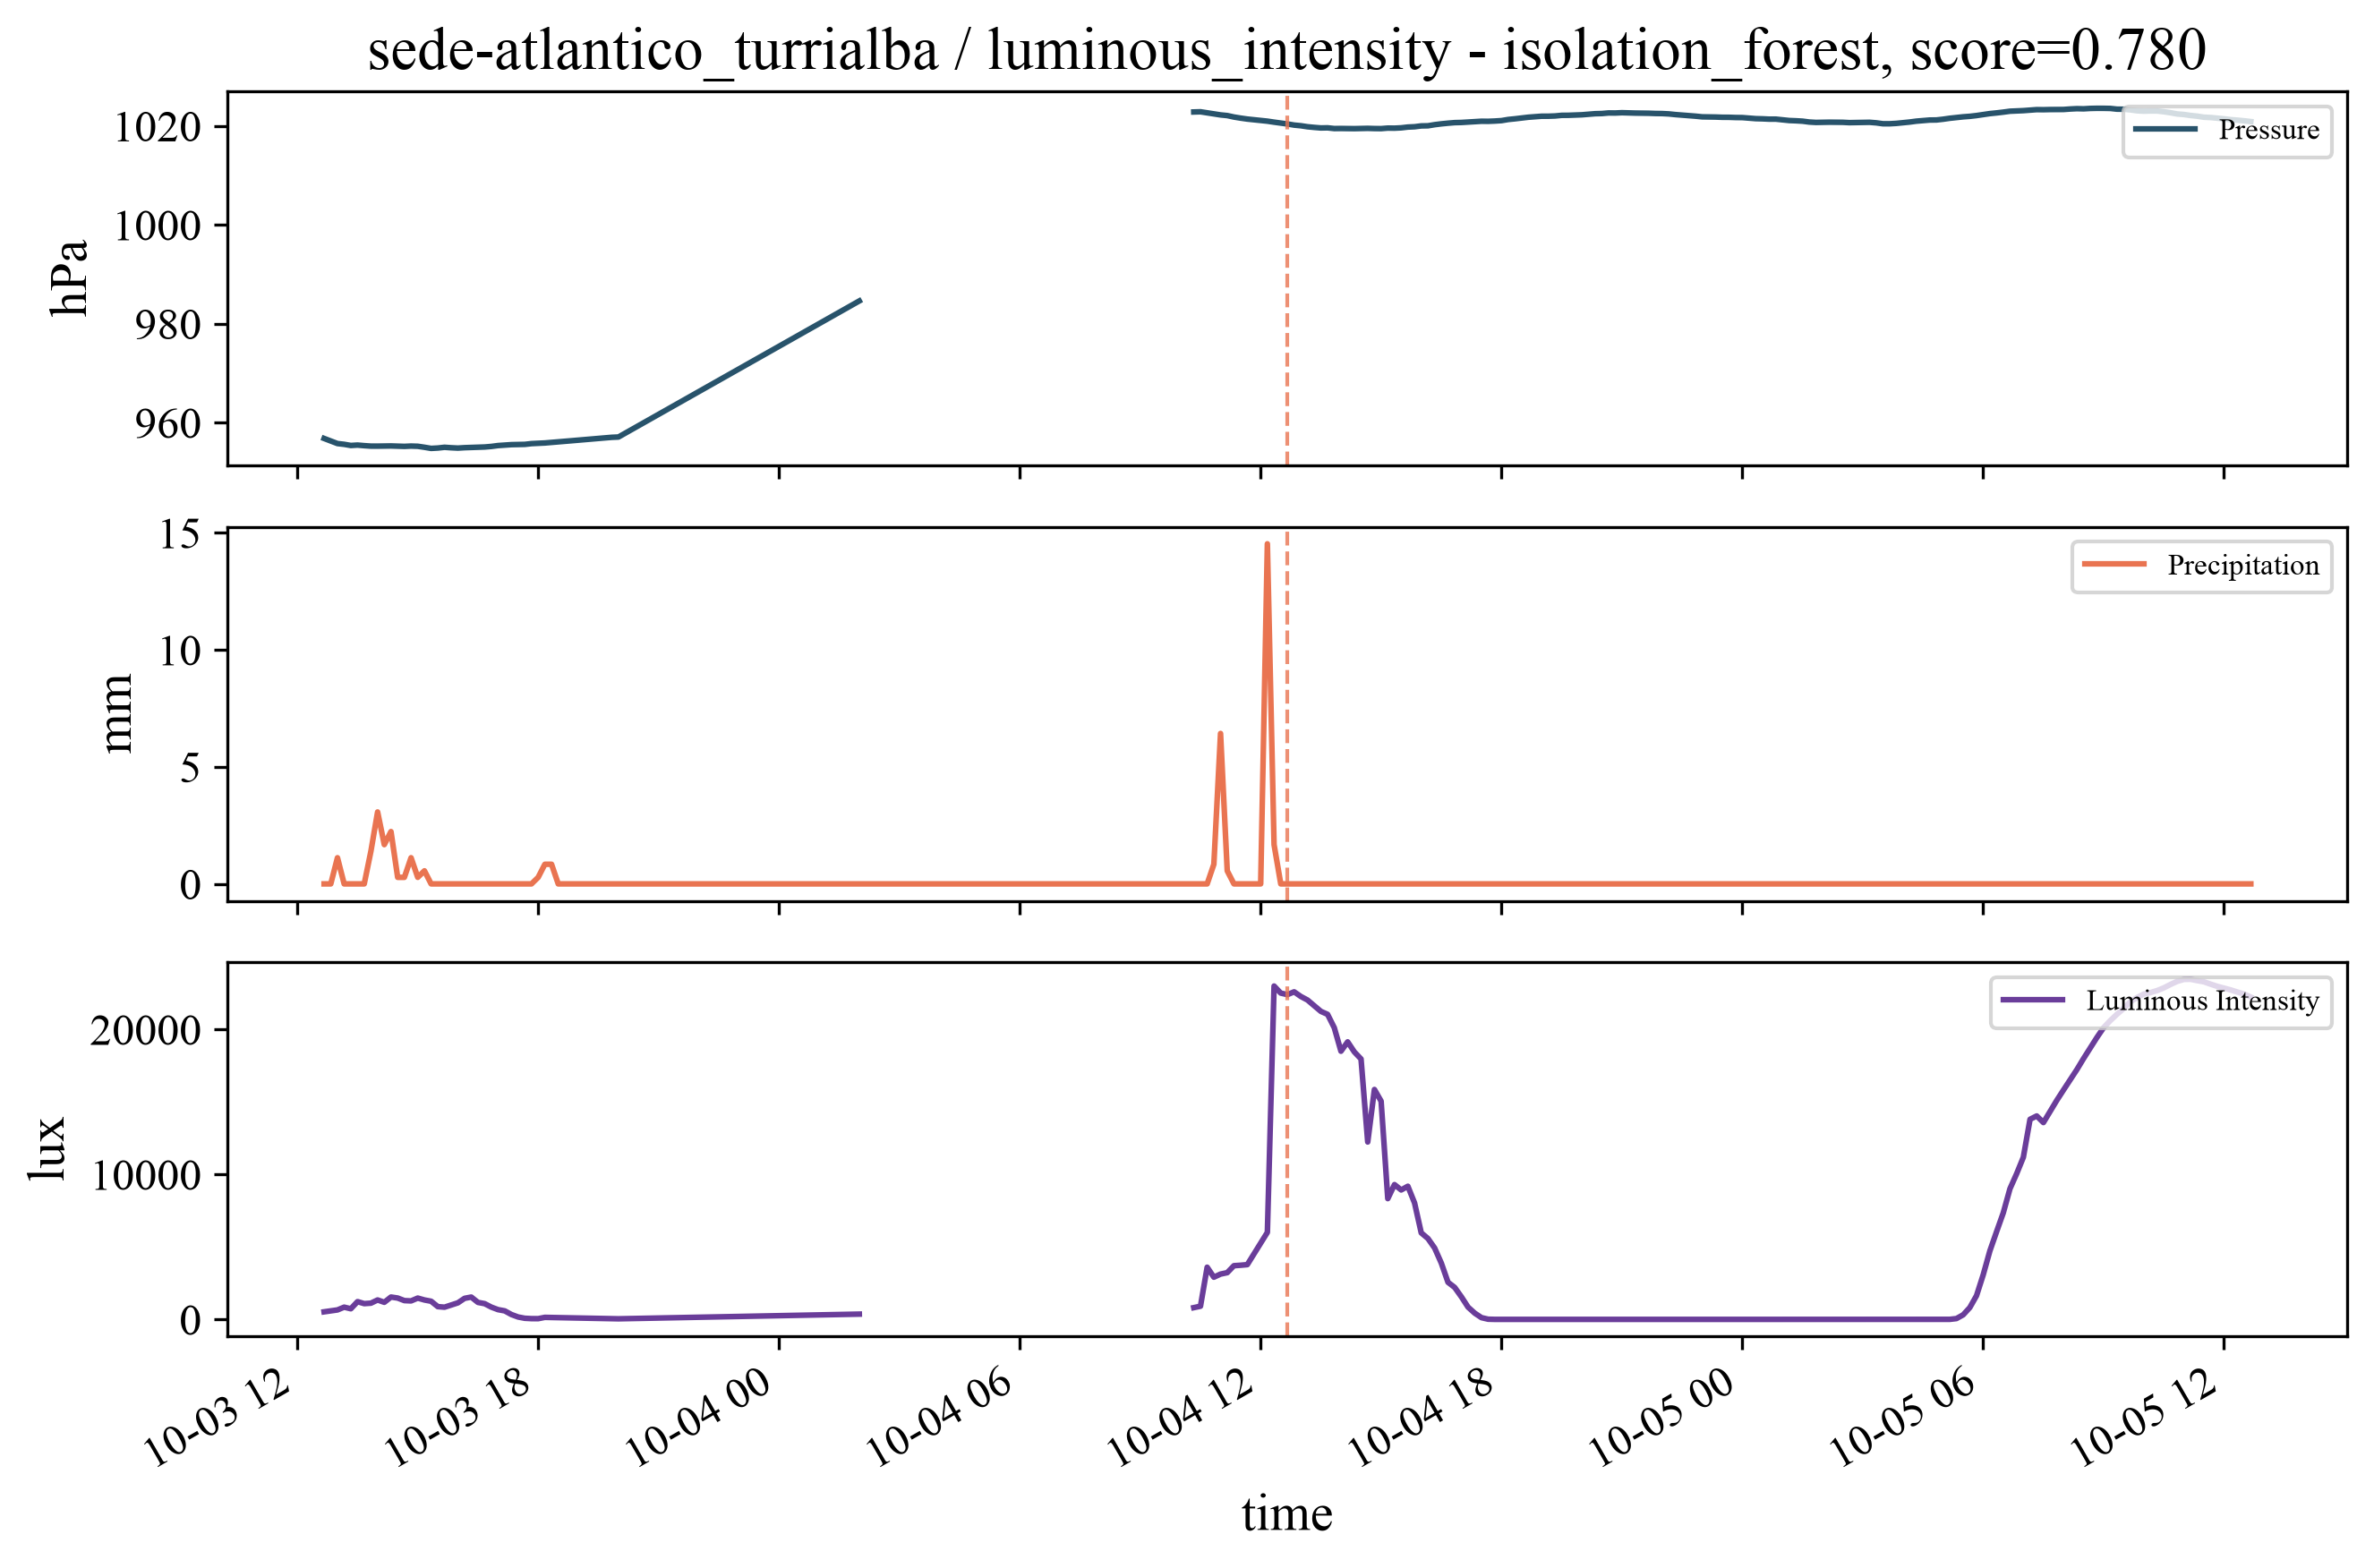

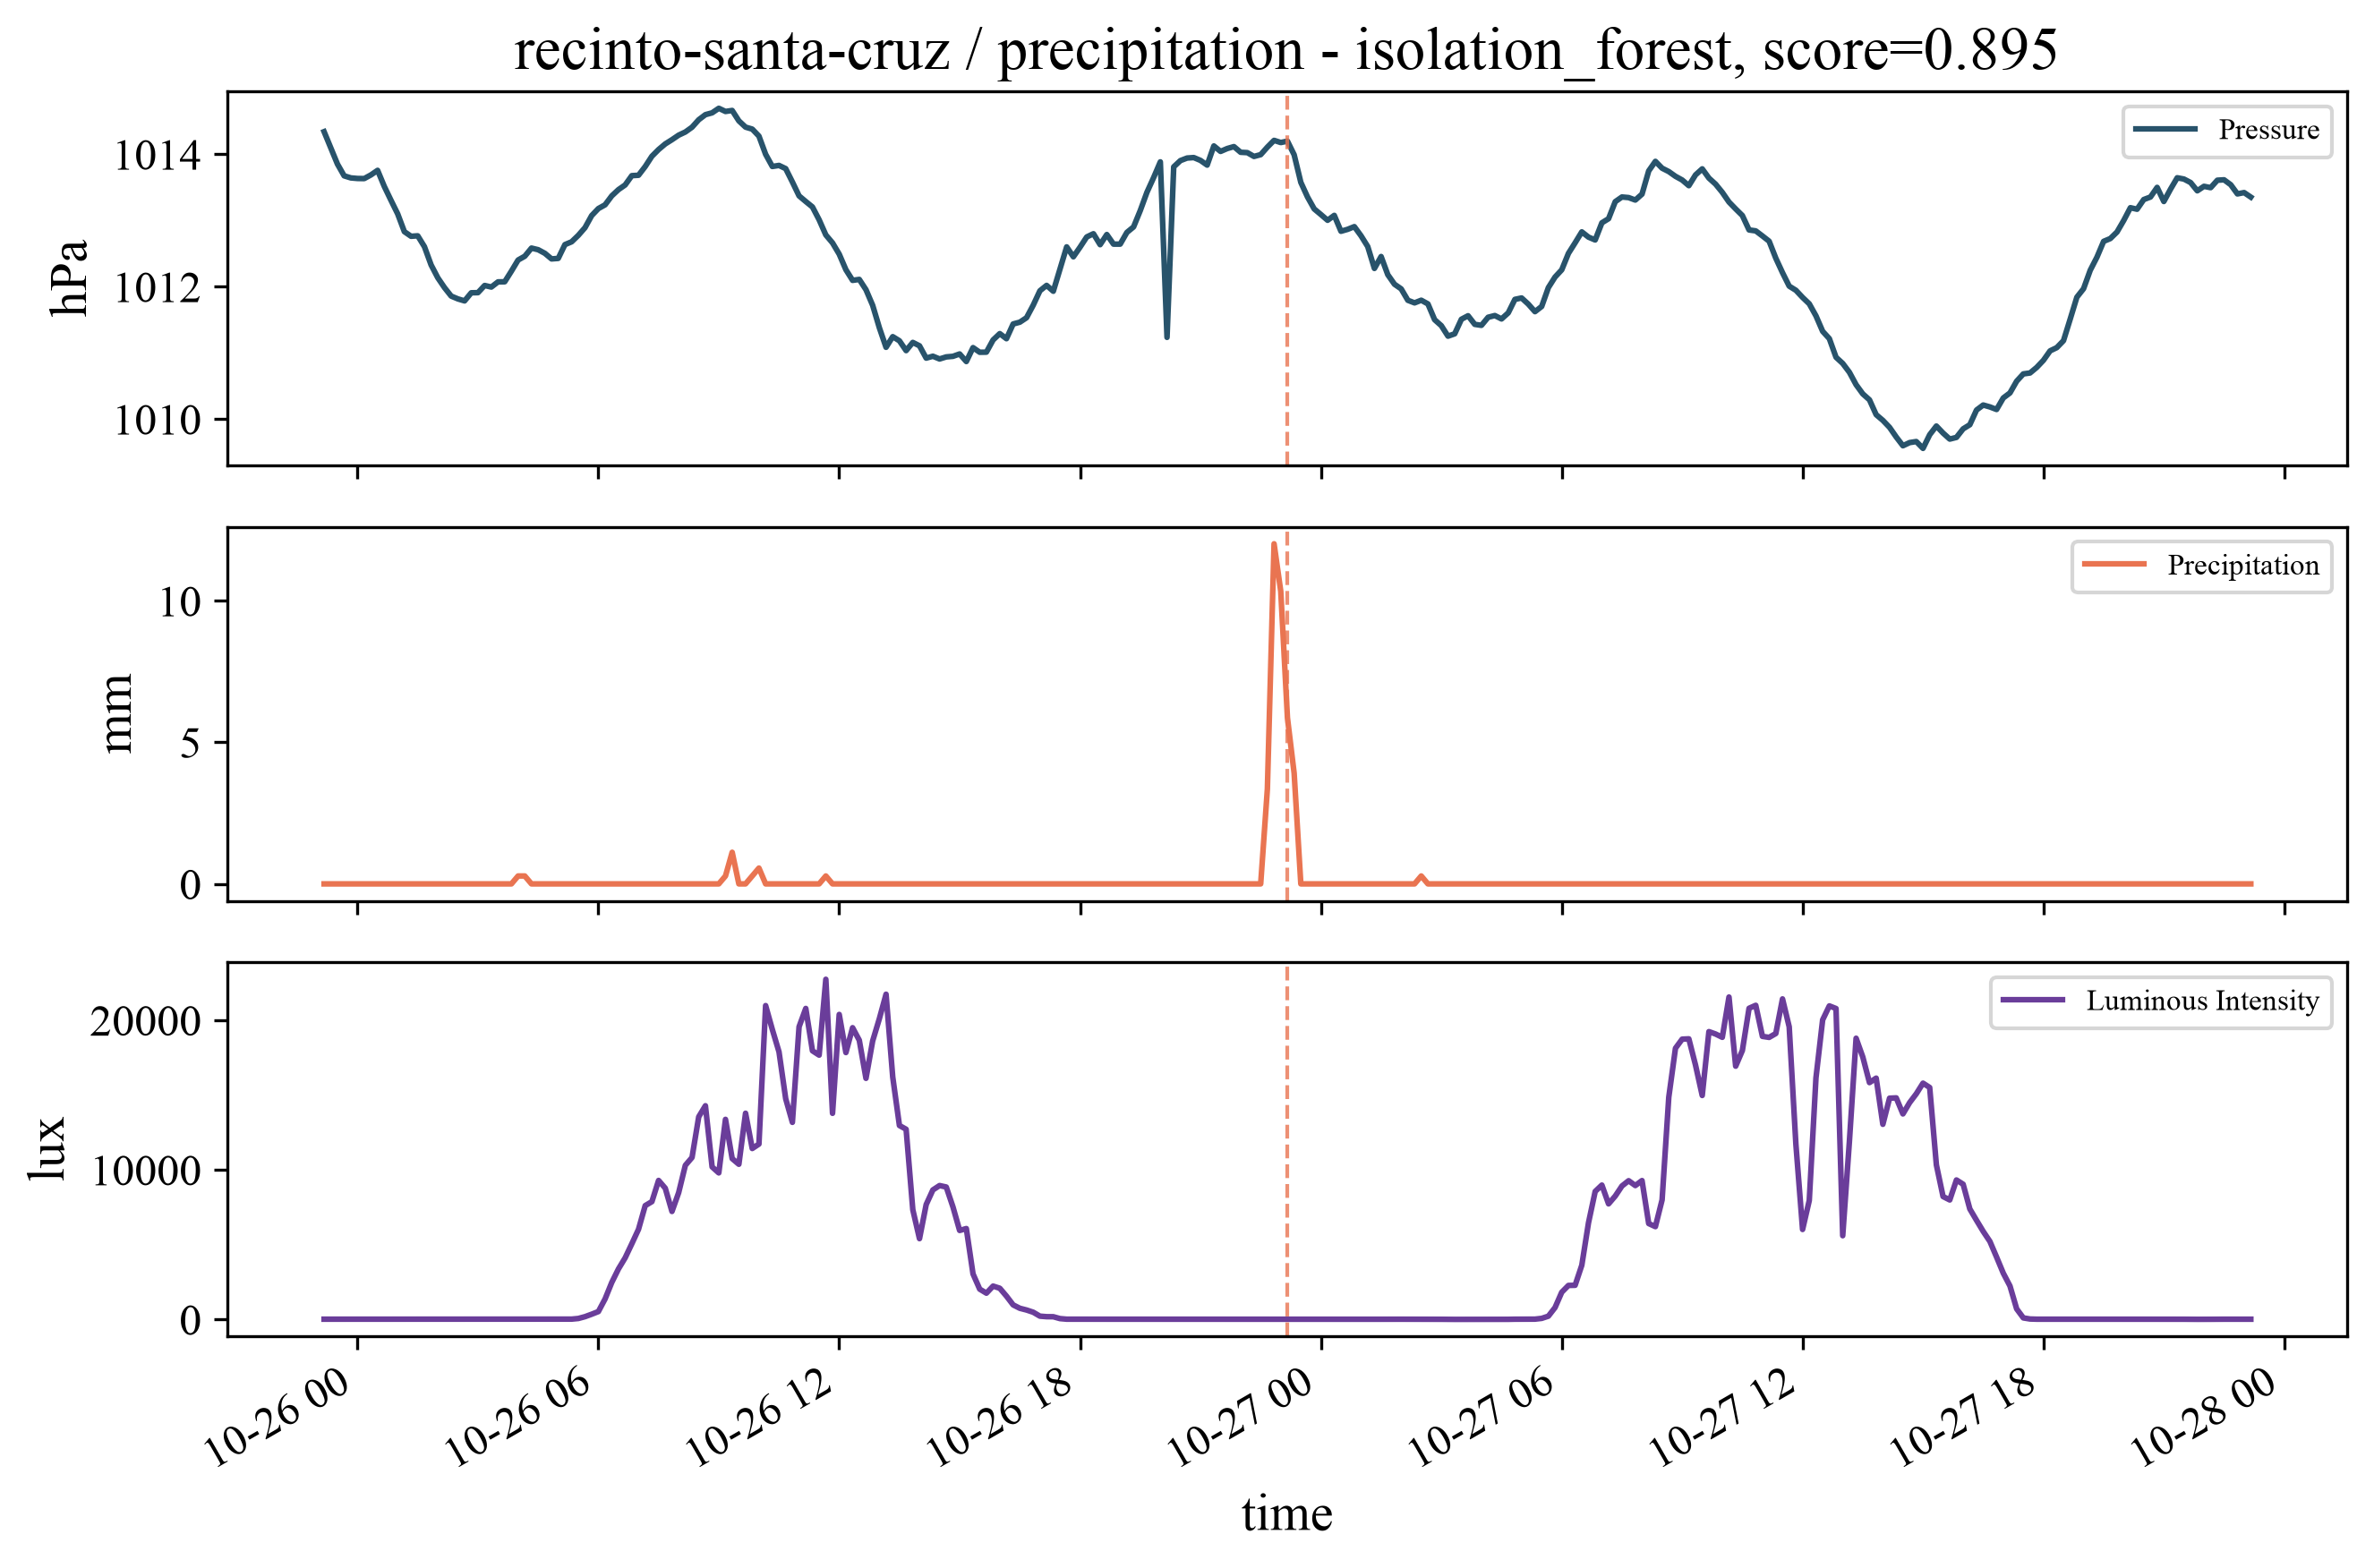

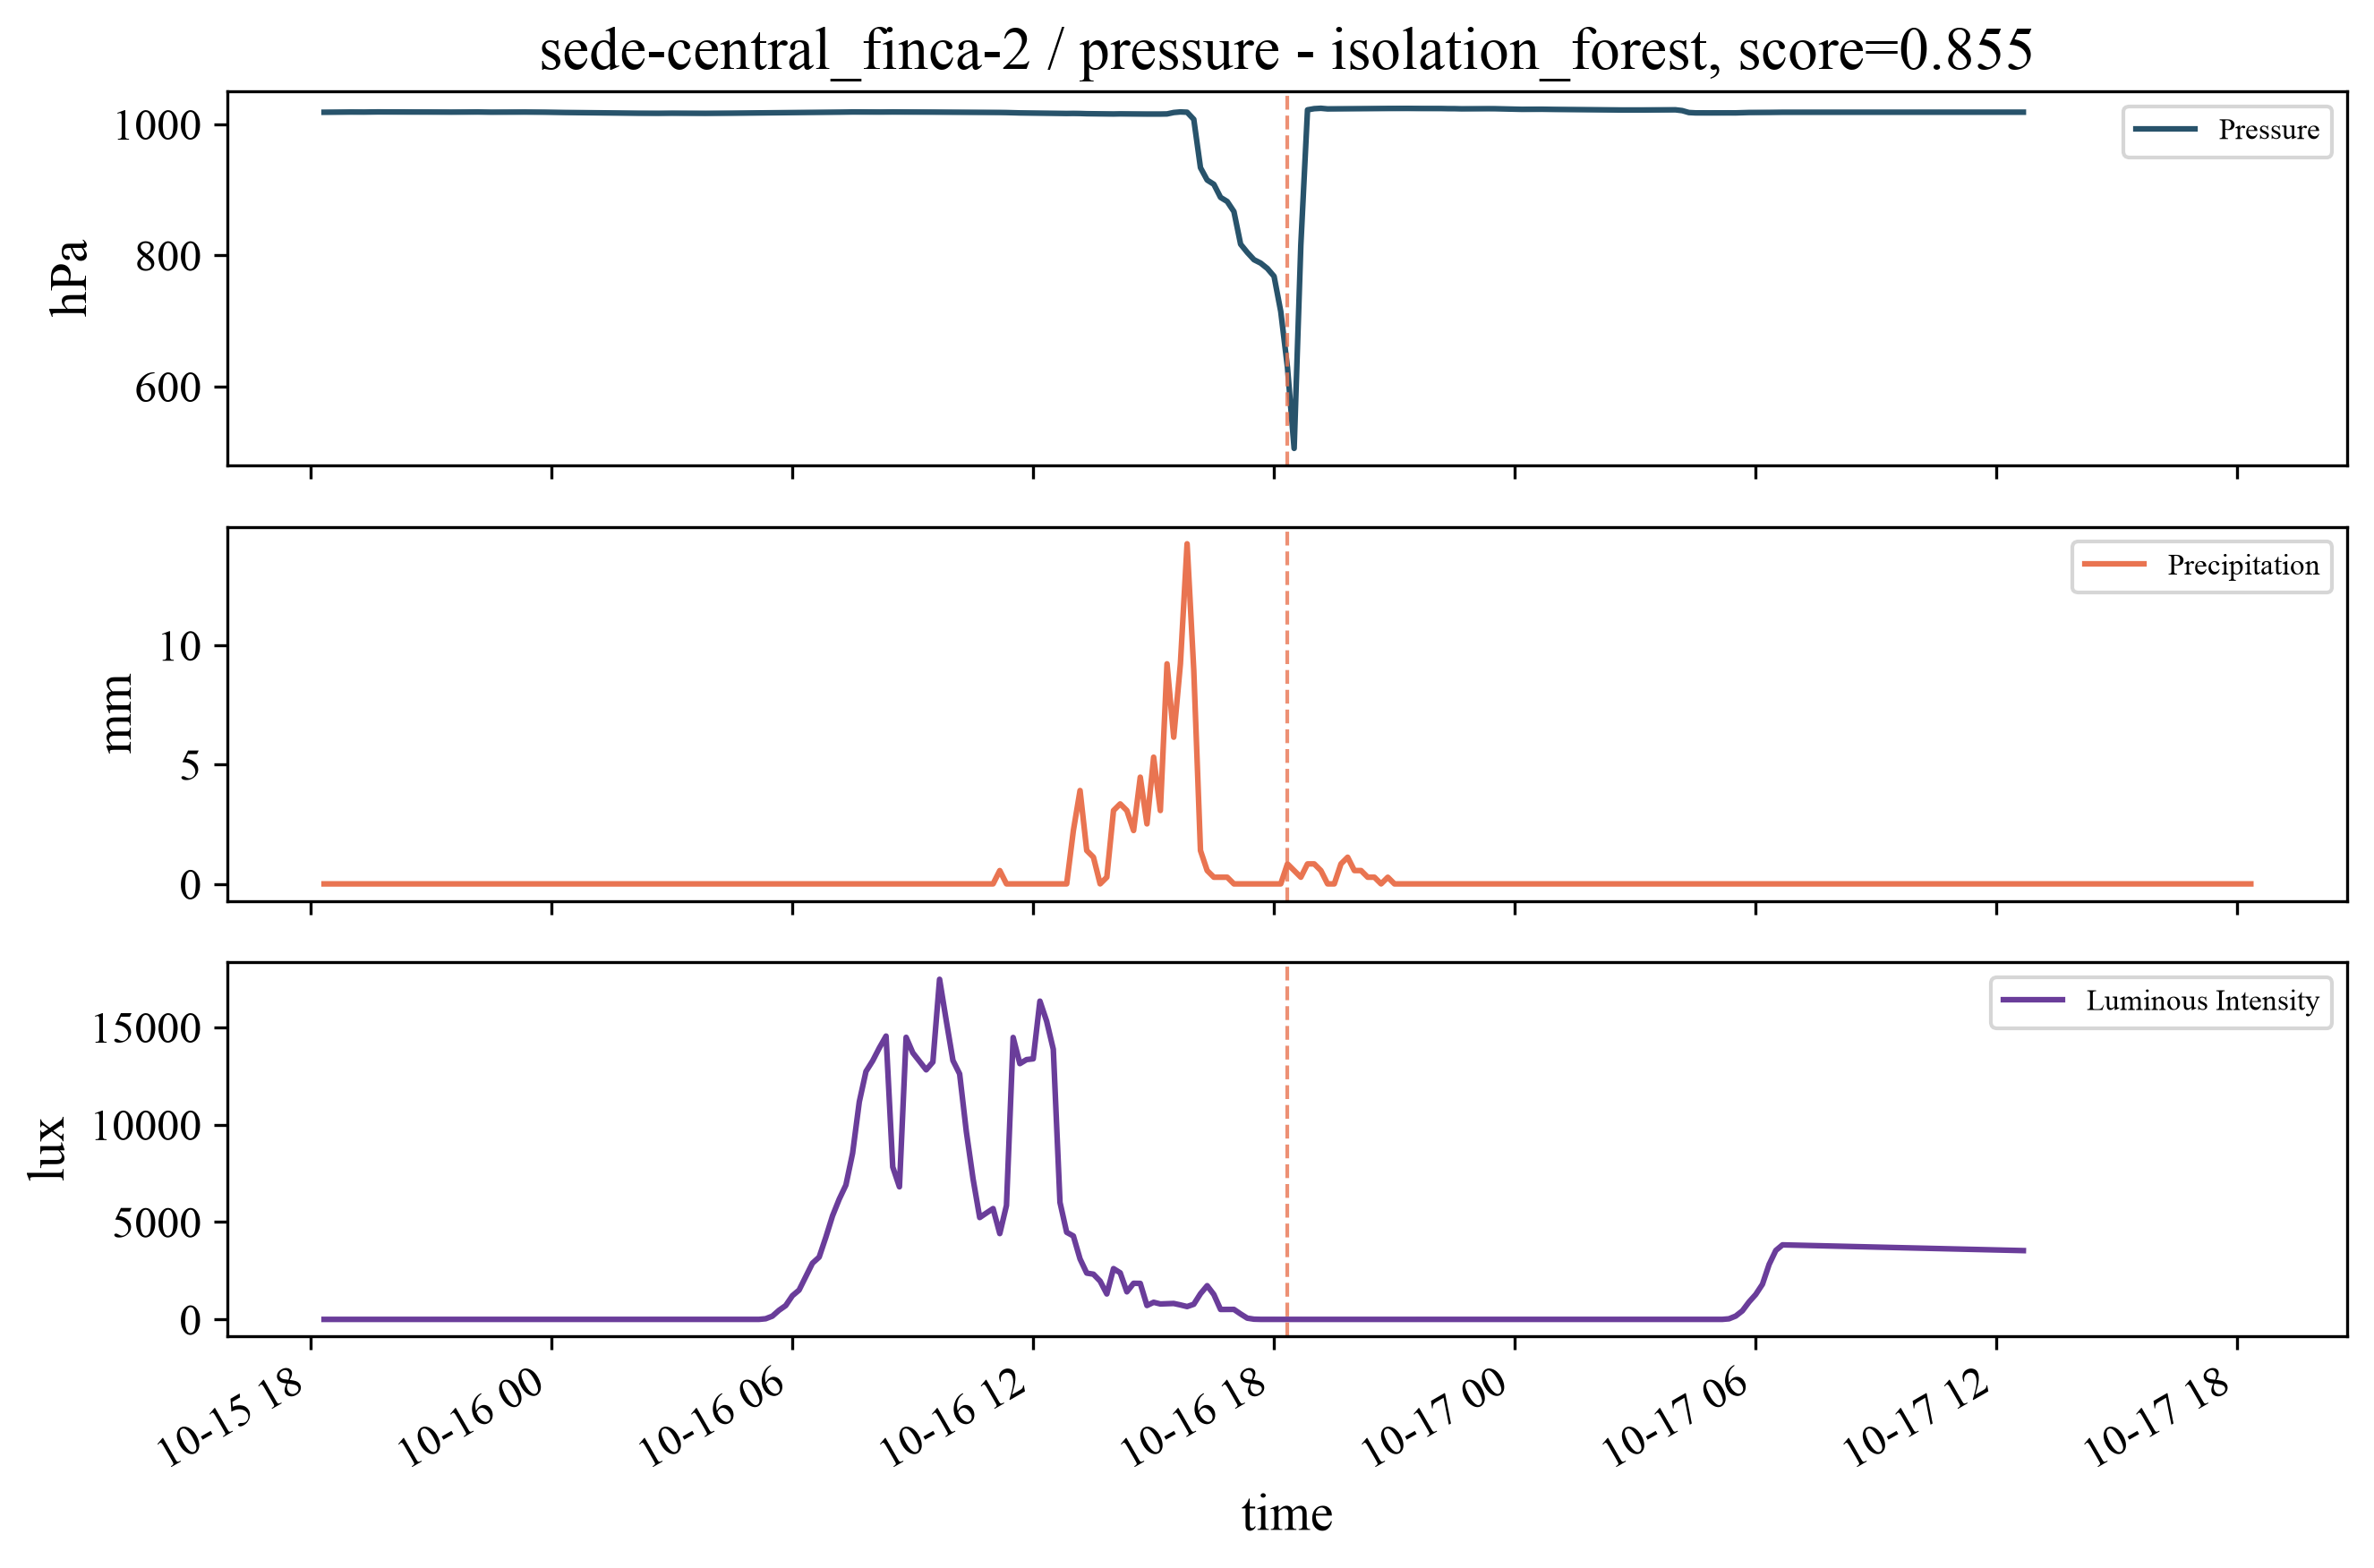

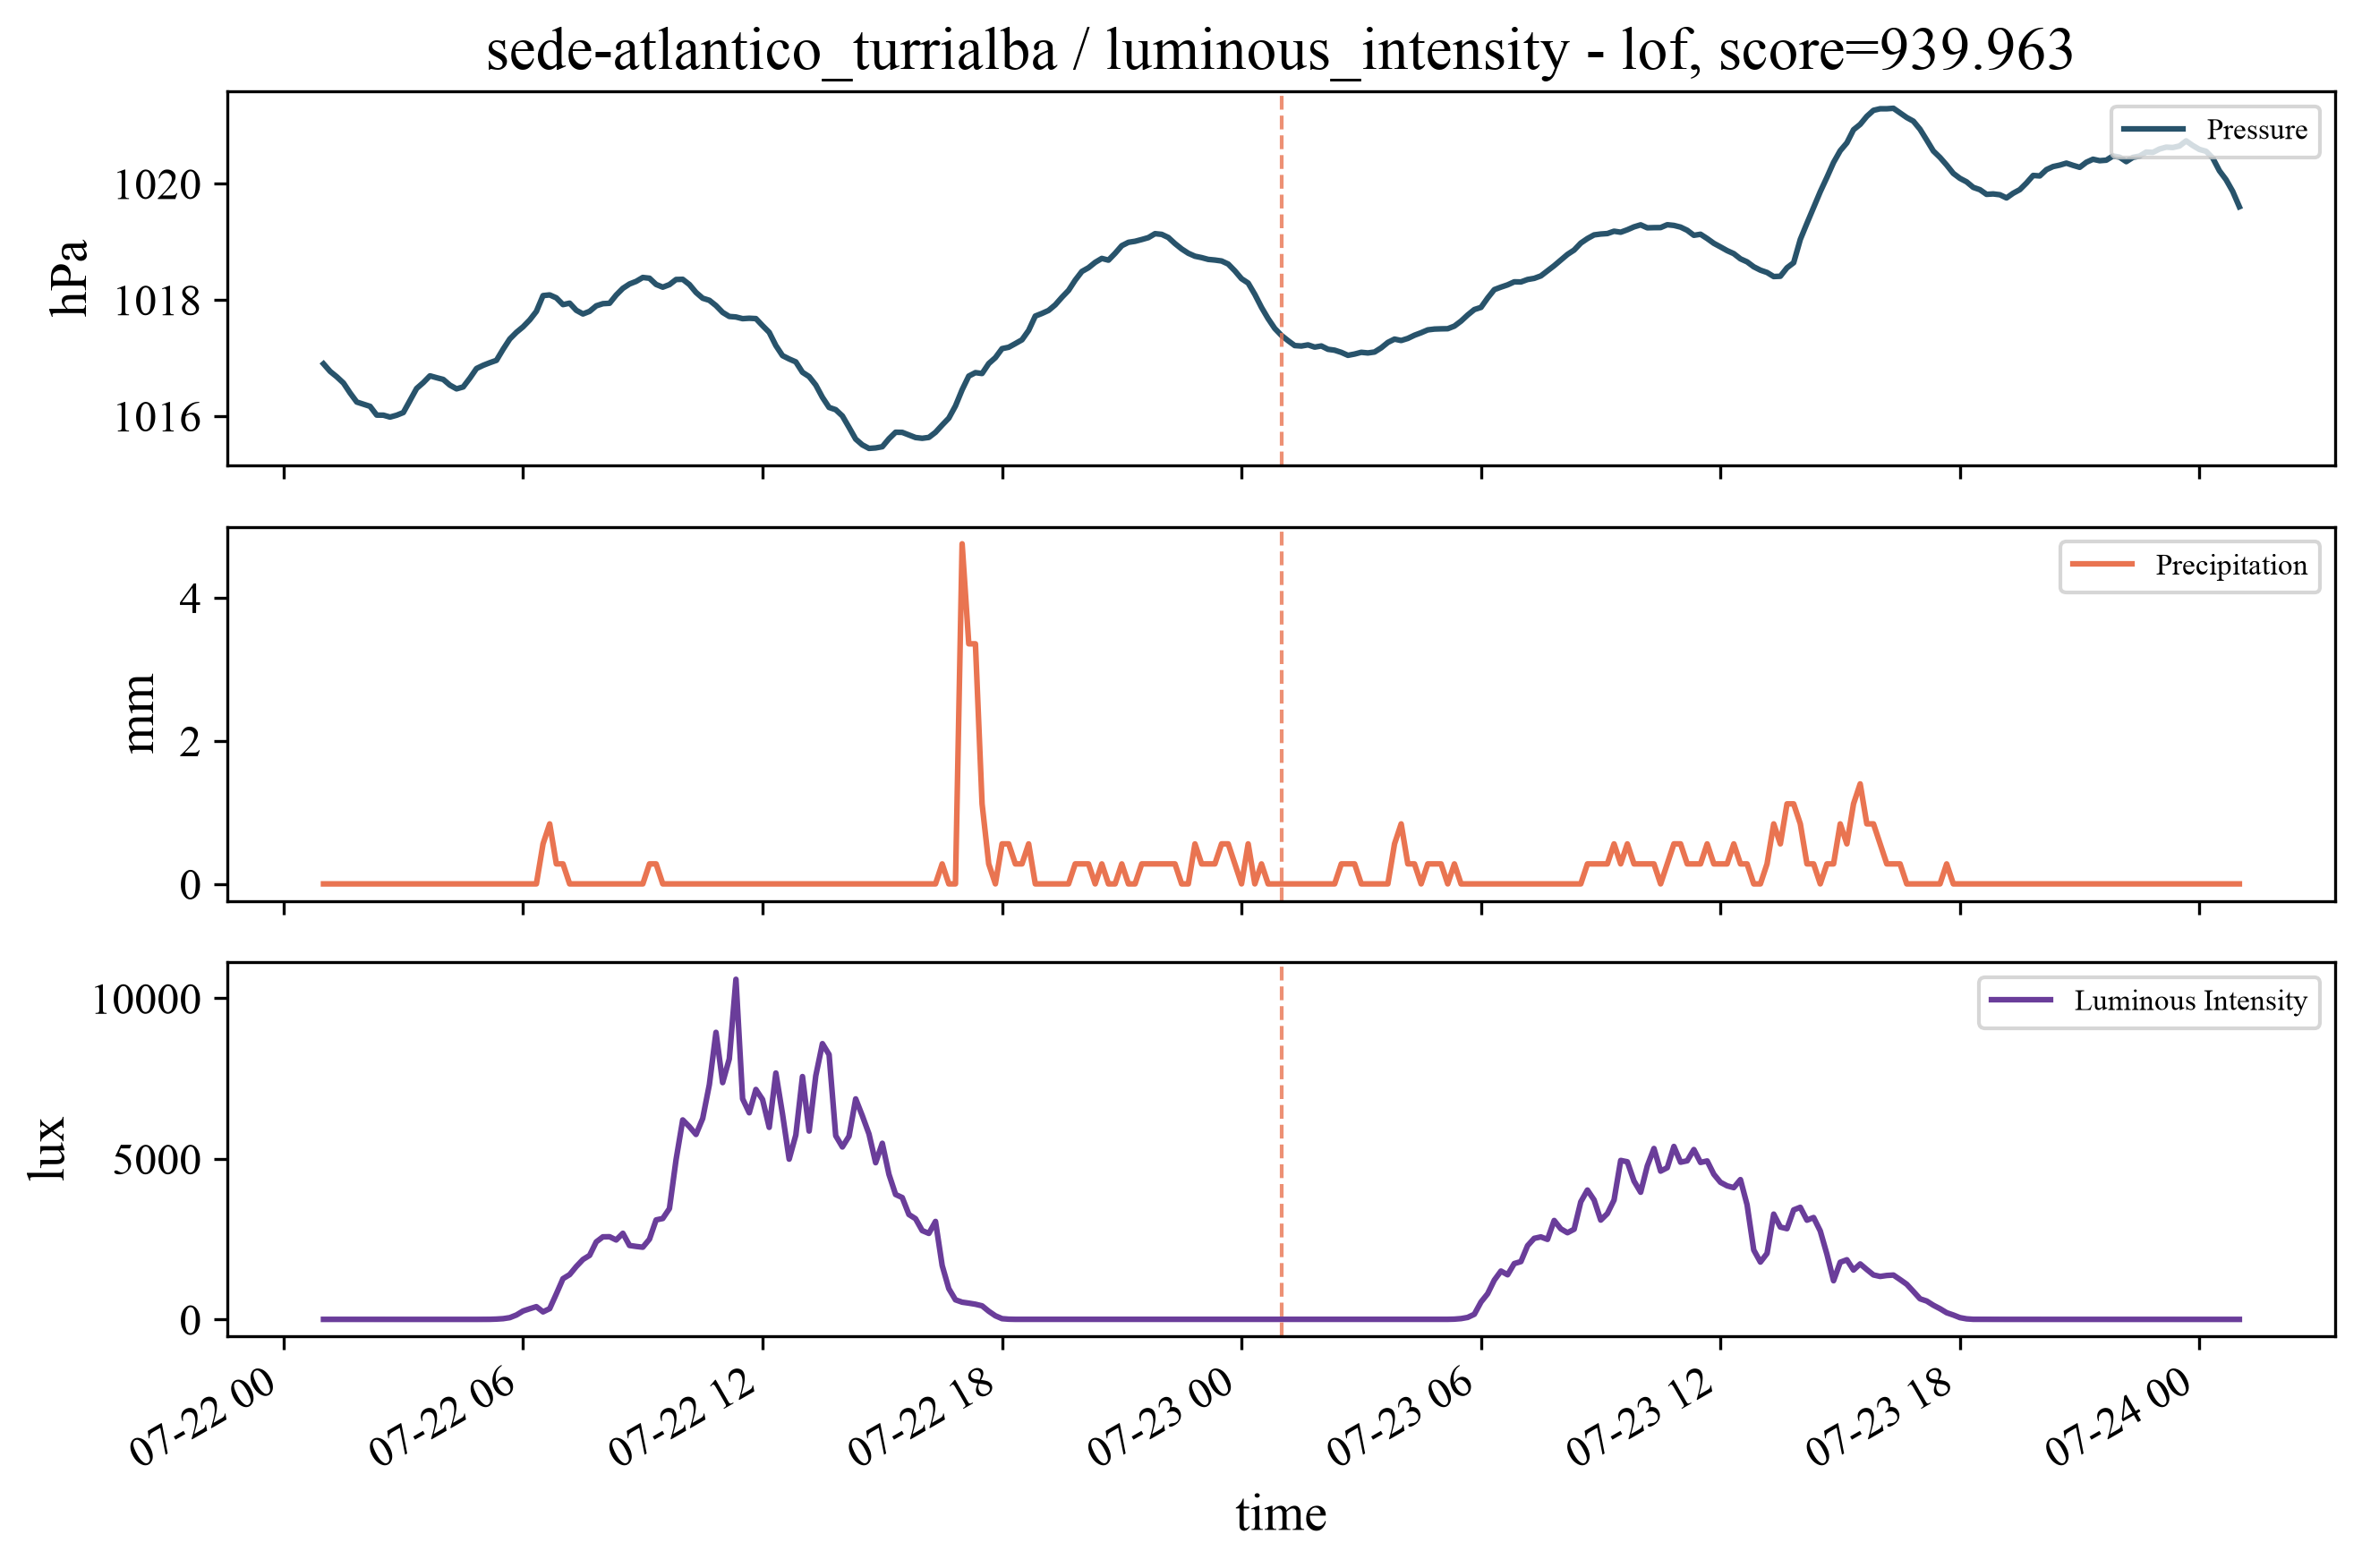

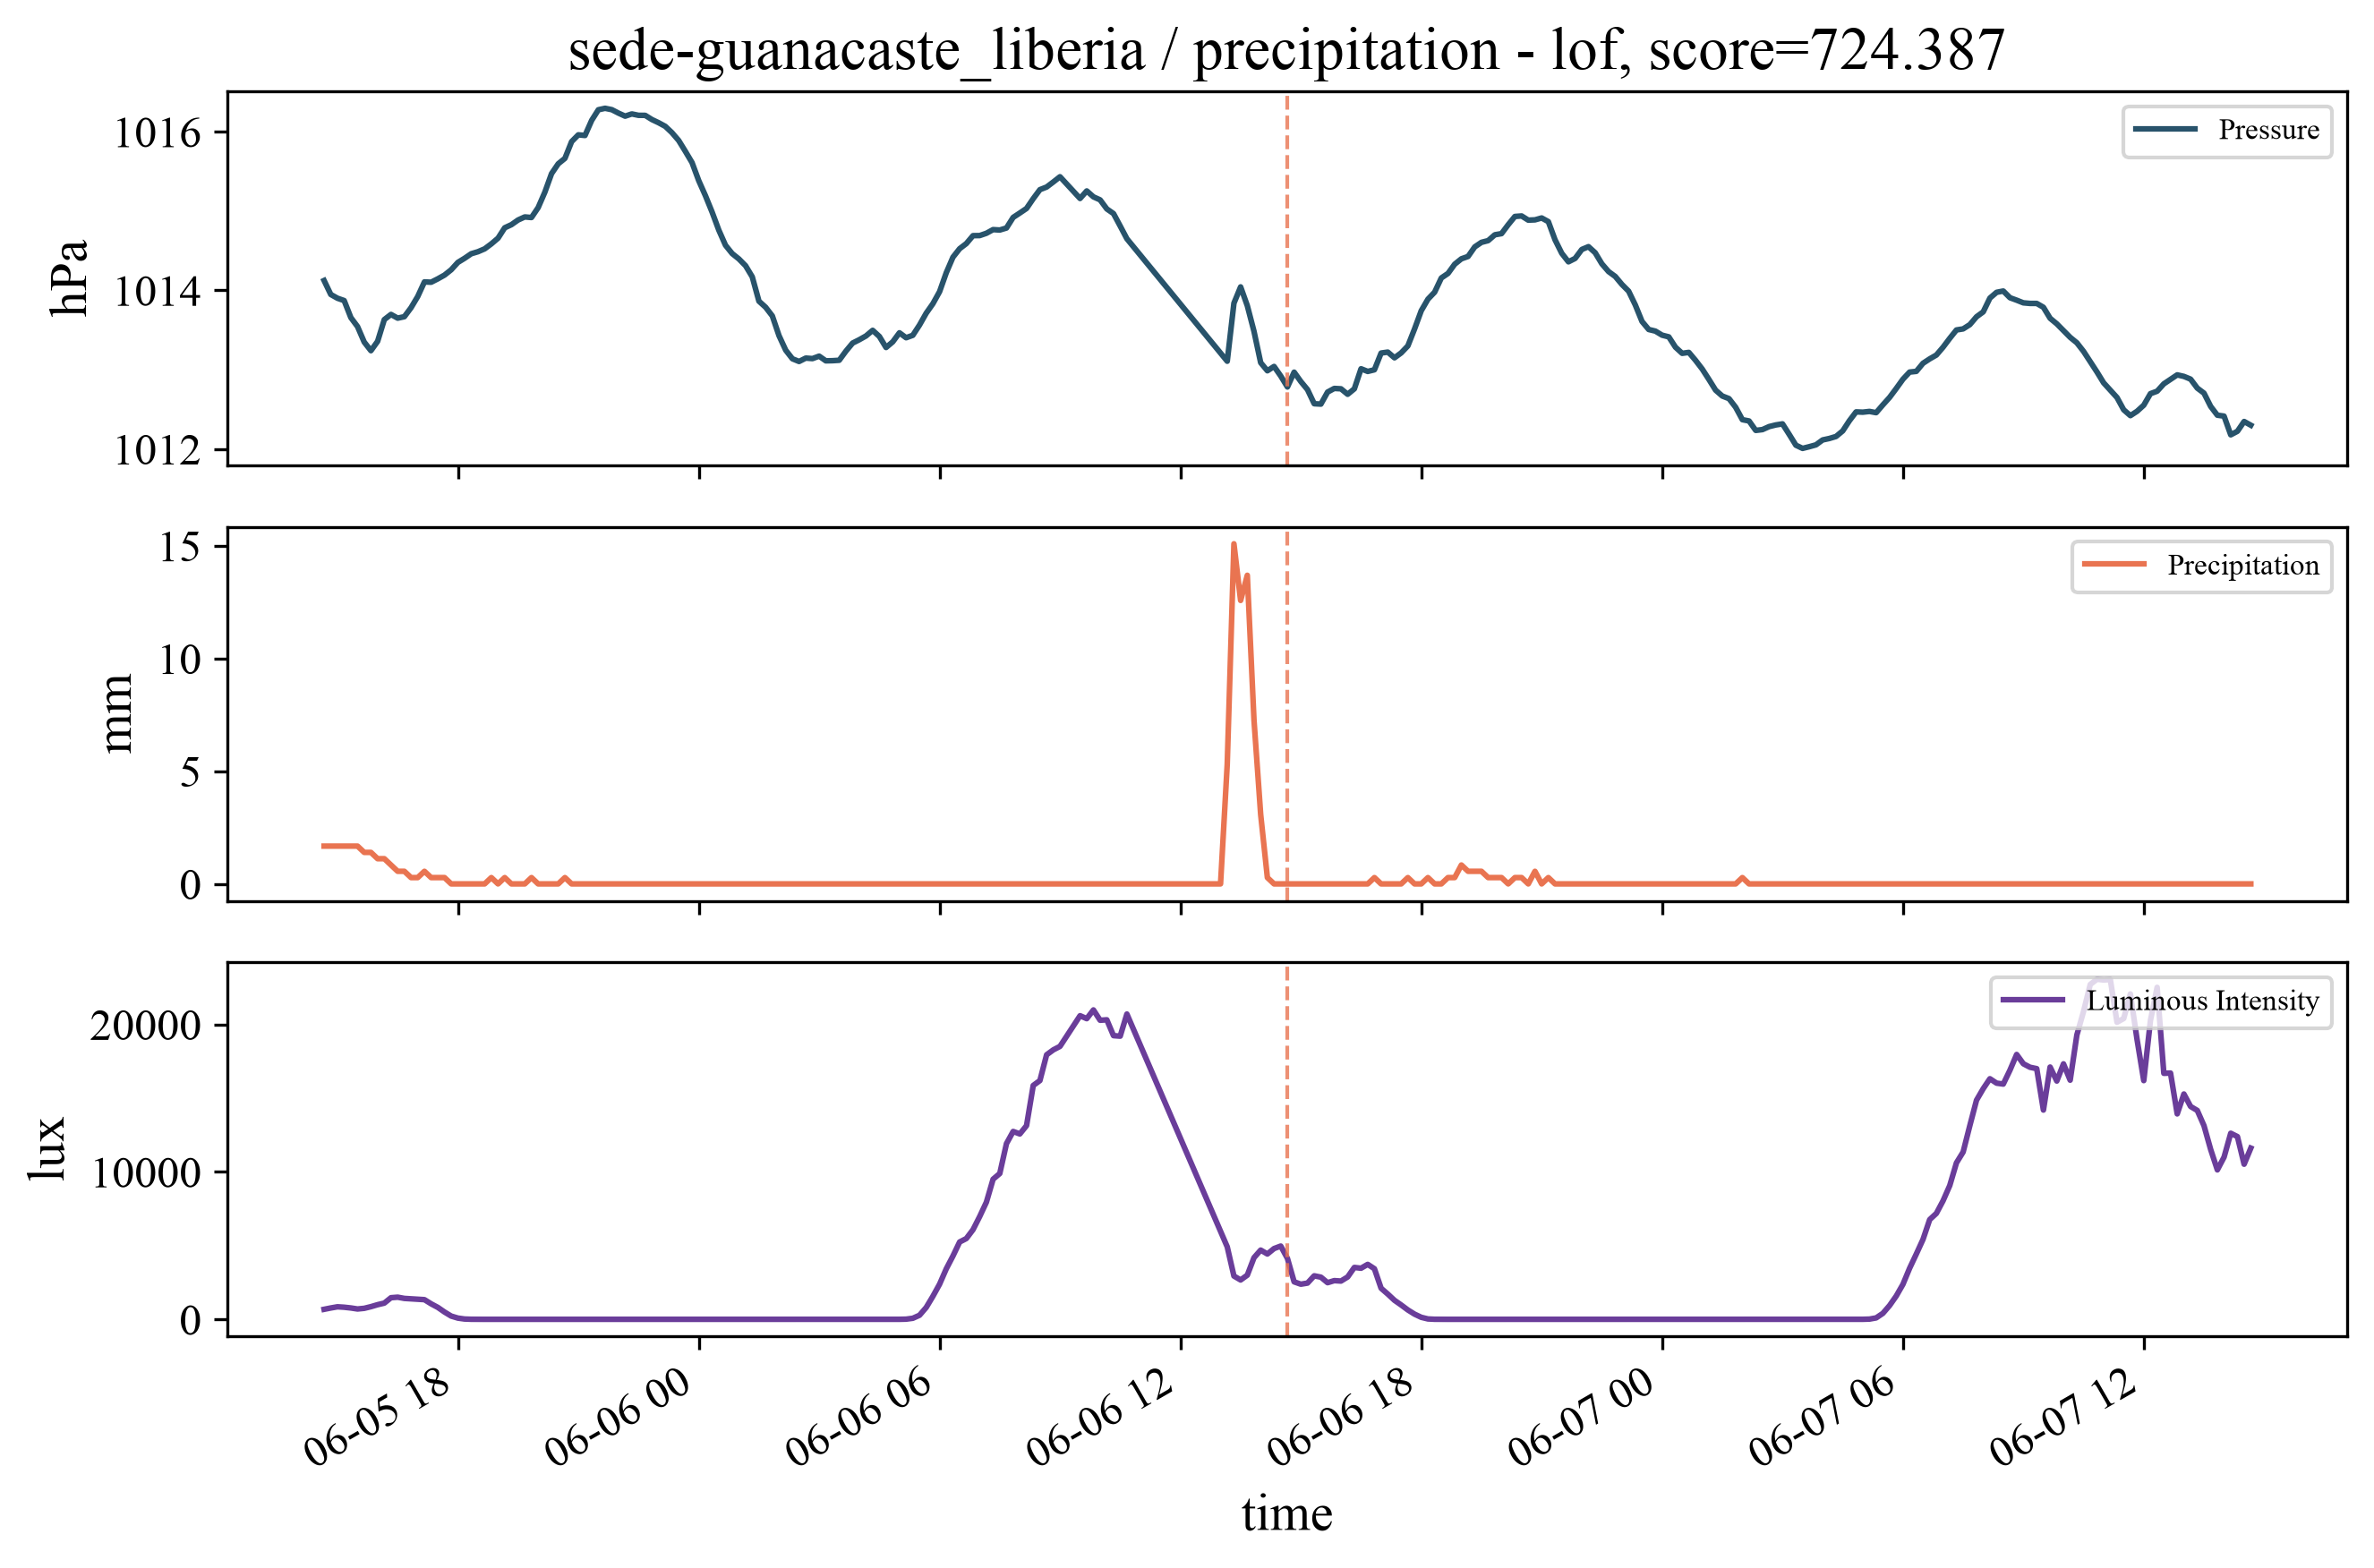

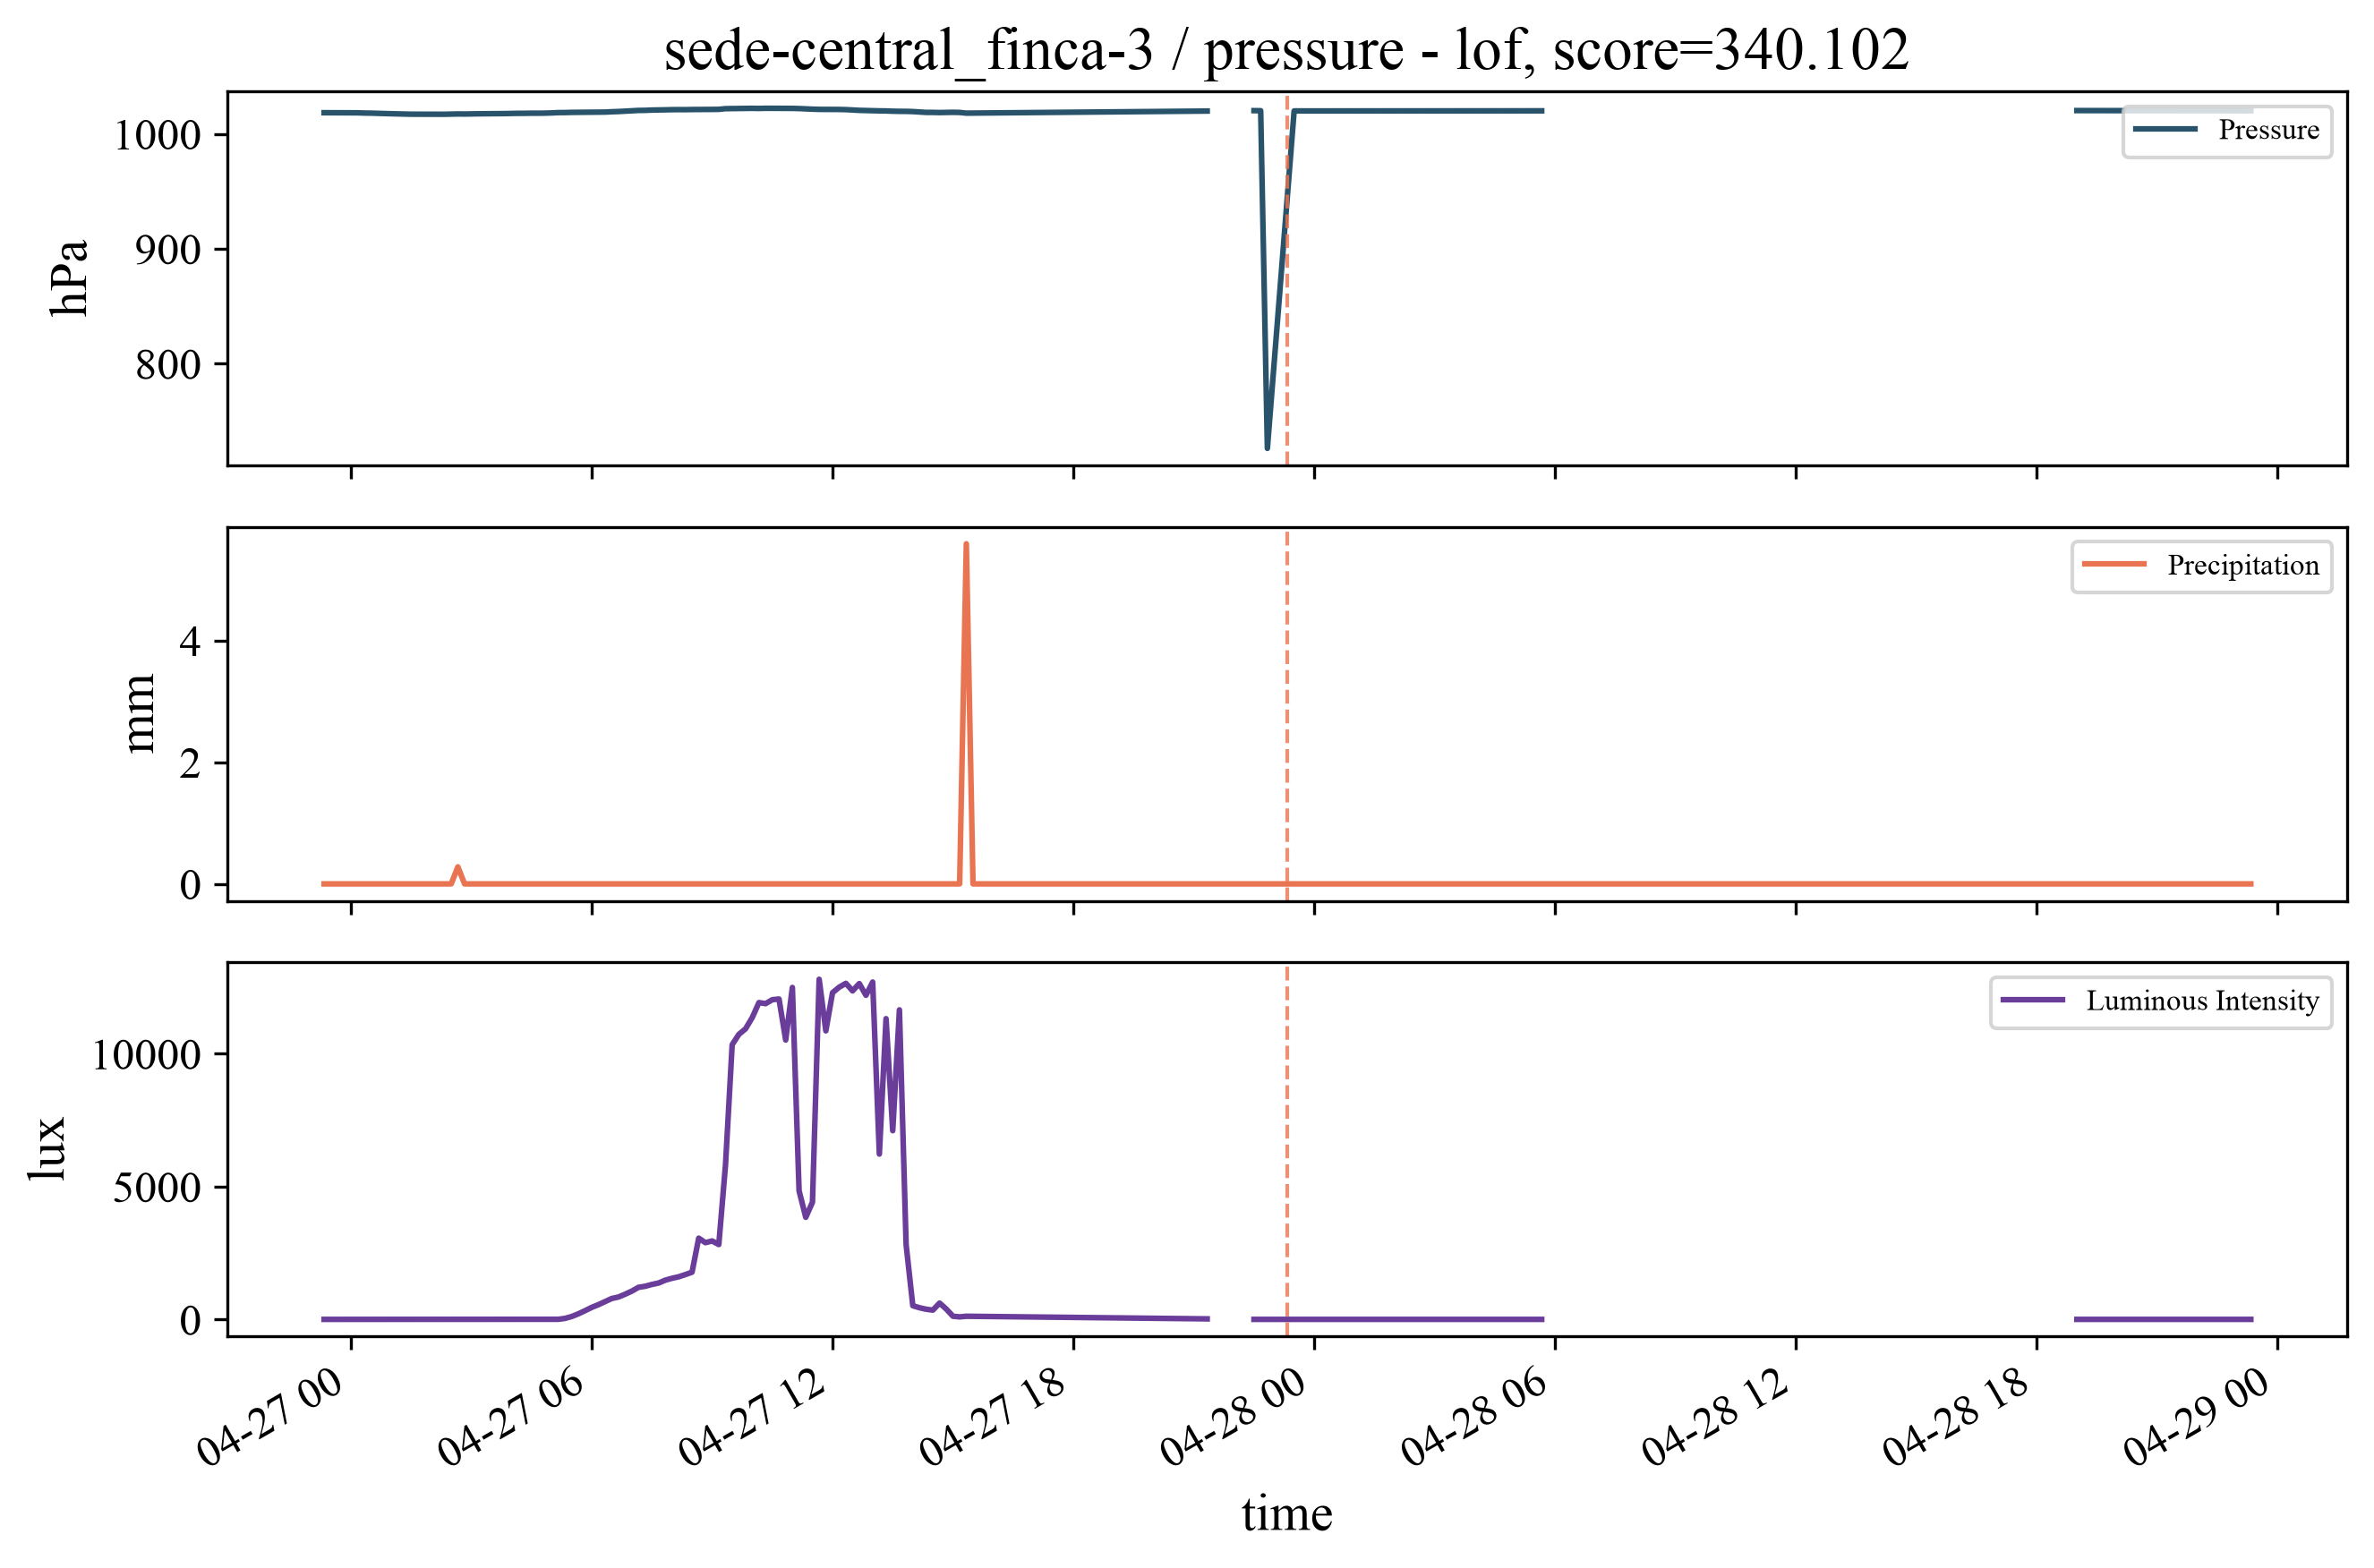

In [7]:
def plot_flagged(
    station: str, sensor: str, center, score, method: str, half_span=pd.Timedelta("24h")
):
    df10 = station_frames[station]
    window = df10.loc[center - half_span : center + half_span]
    fig, axes = plt.subplots(3, 1, figsize=(9, 6), sharex=True)
    cols = ["pressure", "precipitation", "luminous_intensity"]
    units = {"pressure": "hPa", "precipitation": "mm", "luminous_intensity": "lux"}
    for ax, col, color_name in zip(axes, cols, PALETTE_ORDER):
        ax.plot(
            window.index,
            window[col],
            color=PALETTE[color_name],
            label=pretty_label(col),
        )
        ax.axvline(
            center,
            color=PALETTE["burnt_sienna"],
            linestyle="--",
            linewidth=1,
            alpha=0.8,
        )
        ax.set_ylabel(units[col])
        ax.legend(loc="upper right", fontsize=8)
    axes[0].set_title(f"{station} / {sensor} - {method}, score={score:.3f}")
    axes[-1].set_xlabel("time")
    fig.autofmt_xdate()
    fig.tight_layout()
    return fig


flagged = detections[detections["flagged"]].copy()
# For LOF, exclude the epsilon-driven tie regime so the plotted example is
# one the score is actually informative about.
plottable = flagged[(flagged["method"] != "lof") | (flagged["score"] <= 1e3)]

top = (
    plottable.sort_values("score", ascending=False)
    .groupby(["method", "sensor"])
    .head(1)
)
for _, row in top.sort_values(["method", "sensor"]).iterrows():
    plot_flagged(
        row["station"], row["sensor"], row["timestamp"], row["score"], row["method"]
    )
    plt.show()

## Closing note

Two of the five method families are now on disk in the shared schema
(`step3_zscore_family.parquet`, `step4_density_isolation.parquet`).
Nothing here is validated against ground truth, and the flagged rates
above are not evidence about how many real anomalies exist — they are the
consequence of each method's own published cutoff applied to this data,
which is exactly why the sensitivity table is stored alongside them.

Two properties of this step matter for Step 7 specifically: the tie
degeneracy on the zero-inflated channels, which is a method-specific
artifact of LOF rather than a property of the data, and the fact that the
two methods here operate on 1-hour window features while Step 3 operates
on 6-hour rolling statistics — so a disagreement between the corners is
partly a disagreement about time scale, and should not be read purely as a
disagreement about what is anomalous.